# Ridge Linear Regression: Visualizations and Bias-Variance tradeoff

## Ridge Linear Regression: Visualizations and the Bias–Variance Trade-off

In this notebook we explore two important concepts in machine learning:

1. **The geometry of linear regression optimization**
2. **The bias–variance trade-off introduced by regularization**

- **Bias** measures how far the average prediction is from the true function
- **Variance** measures how much predictions change across datasets

We will use **synthetic data** so that we fully control the underlying data generation process.

The notebook is divided into two main parts:

1. **Error surface visualization**  
   We visualize how the Mean Squared Error (MSE) changes depending on the regression coefficients. This helps us understand the optimization landscape of linear regression and how **multicollinearity** affects it.

2. **Bias–variance simulation with Ridge regression**  
   We run repeated simulations to empirically observe how increasing the regularization parameter $( \lambda )$  changes the **bias** and **variance** of the model.

The goal is to build an **intuition** for why regularization improves generalization.

## Error Surface Visualization

In linear regression we estimate the model parameters \( w \) by minimizing the **Mean Squared Error (MSE)**:

$
[L(w) = ||y - Xw||^2]
$

where:

- $(X)$ is the feature matrix
- $(y)$ are the target values
- $(w)$ are the regression coefficients

In this example we use **two parameters** $(w_1)$ and $(w_2)$.  
This allows us to visualize the loss function over a grid of possible parameter values.

The code below performs the following steps:

1. Generate a synthetic dataset
2. Create **two highly correlated features** (multicollinearity)
3. Compute the MSE for many possible values of $(w_1)$ and $(w_2)$
4. Plot the result as **contour lines**

Each contour line represents **points with equal loss**.

When features are strongly correlated, the contours become **elongated ellipses**, showing that many parameter combinations produce similar errors. This makes the solution unstable and sensitive to small variations in the data.

<>:72: SyntaxWarning: invalid escape sequence '\m'
<>:88: SyntaxWarning: invalid escape sequence '\l'
<>:72: SyntaxWarning: invalid escape sequence '\m'
<>:88: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_160/2980083065.py:72: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_zlabel('Loss $J(\mathbf{w})$')
/tmp/ipykernel_160/2980083065.py:88: SyntaxWarning: invalid escape sequence '\l'
  ax2.plot(w_ridge[0], w_ridge[1], 'rX', markersize=8, label=f'Ridge Min ($\lambda={lam}$)', zorder=7)


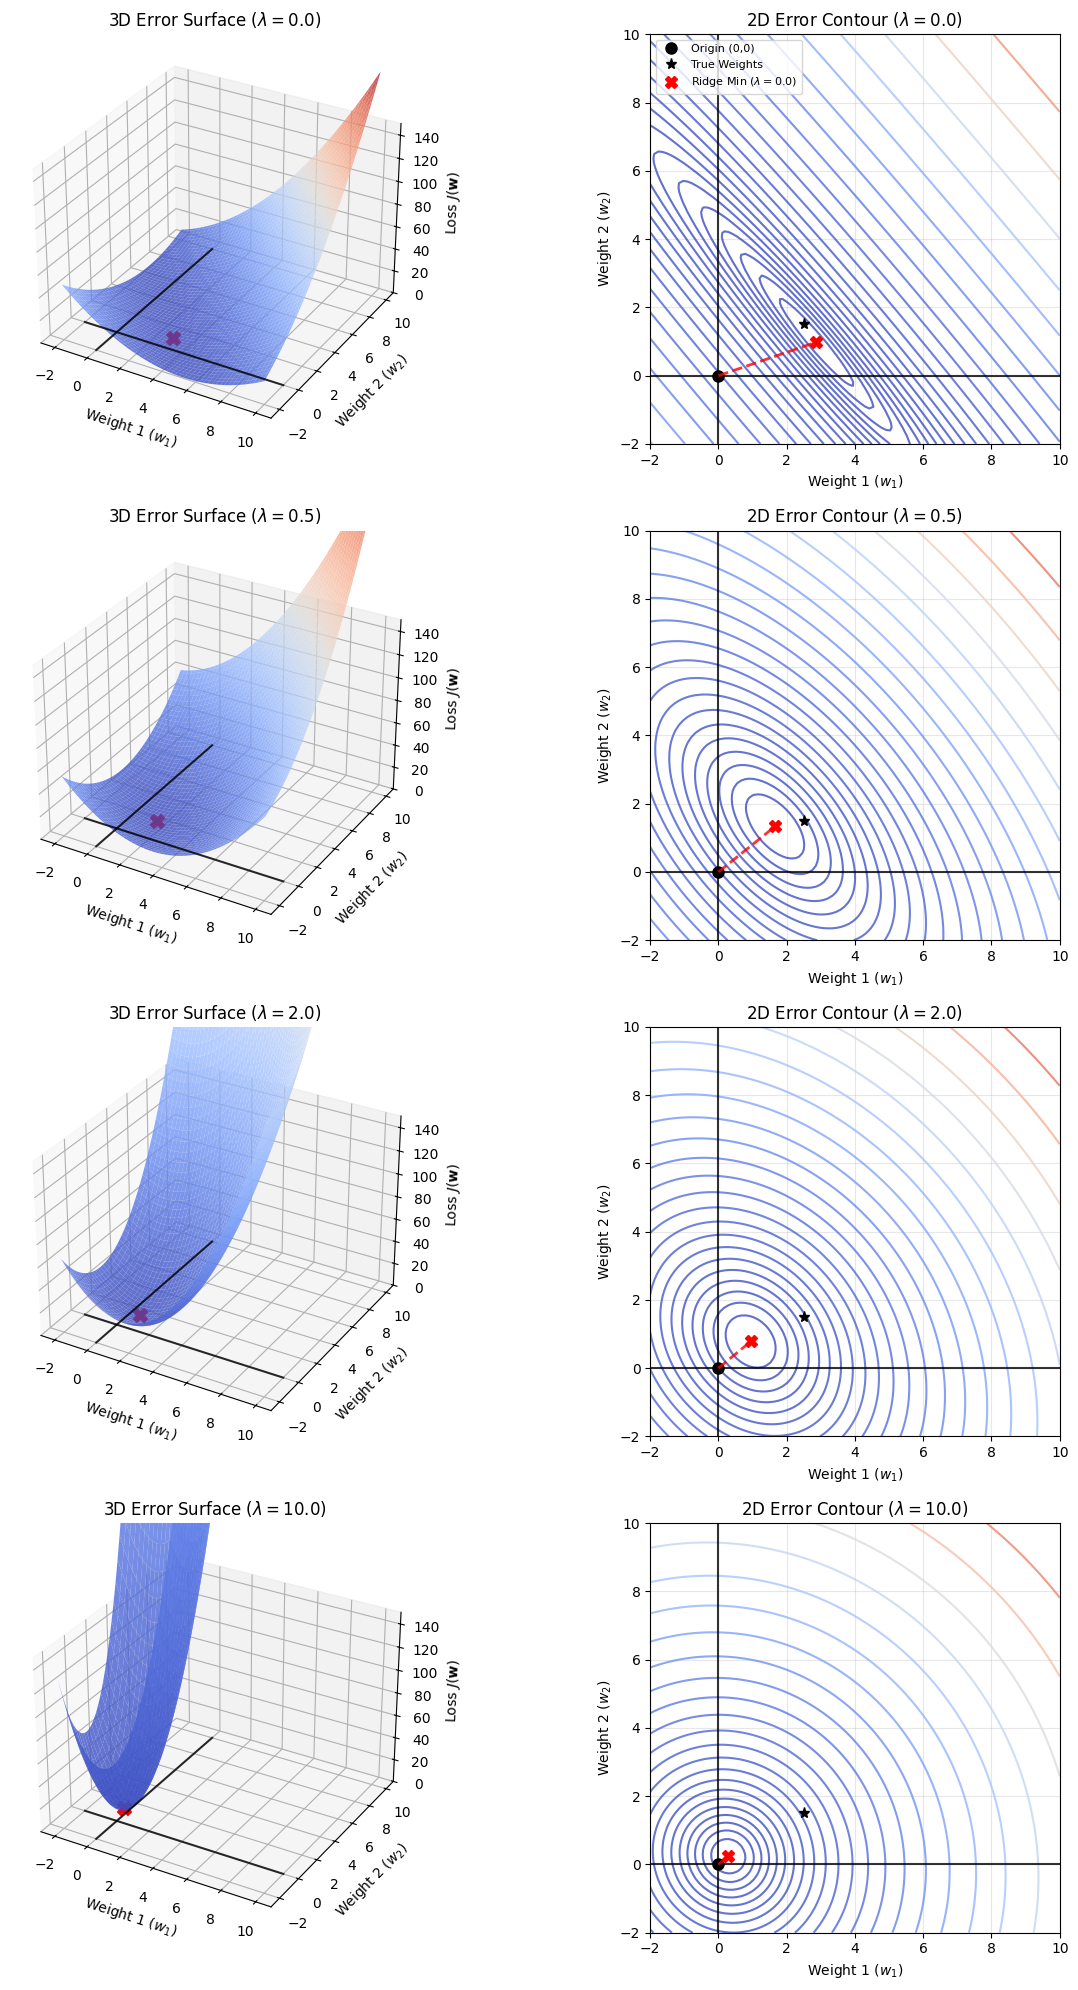

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Setup Data and Define the Grid
# ==========================================
np.random.seed(42)
n_samples = 50

# Define true weights
w_true = np.array([2.5, 1.5])

# Create heavily correlated features (multicollinearity)
# This makes the unregularized MSE contours elliptical, stretching out the "valley"
X1 = np.random.normal(0, 1, n_samples)
X2 = 0.8 * X1 + np.random.normal(0, 0.25, n_samples)
X = np.column_stack((X1, X2))
y = X @ w_true  + np.random.normal(0, 0.5, n_samples)

# Define a grid of w1 and w2 values to compute the error landscape
w1_range = np.linspace(-2, 10, 100)
w2_range = np.linspace(-2, 10, 100)
W1, W2 = np.meshgrid(w1_range, w2_range)

# Flatten grid to (10000, 2) to compute the error function vectorized
W_flat = np.c_[W1.ravel(), W2.ravel()]

# Compute the base Mean Squared Error (MSE) over the entire grid
err = X @ W_flat.T - y[:, None]
mse = np.mean(err**2, axis=0)

# Compute the L2 penalty over the grid (w1^2 + w2^2)
l2_penalty = W_flat[:, 0]**2 + W_flat[:, 1]**2

# Define lambda values to visualize (increasing penalty)
lambdas = [0.0, 0.5, 2.0, 10.0]

# ==========================================
# 2. Iterative Plotting
# ==========================================
fig = plt.figure(figsize=(14, 5 * len(lambdas)))

for i, lam in enumerate(lambdas):
    # Compute the total Regularized Error function: J(w) = MSE + lambda * ||w||^2
    J_lam = mse + lam * l2_penalty
    J_grid = J_lam.reshape(W1.shape)

    # Calculate the exact Ridge minimum analytically
    XtX_n = (X.T @ X) / n_samples
    Xty_n = (X.T @ y) / n_samples
    w_ridge = np.linalg.inv(XtX_n + lam * np.eye(2)) @ Xty_n

    # --- Left Plot: 3D Error Surface ---
    ax1 = fig.add_subplot(len(lambdas), 2, 2 * i + 1, projection='3d')
    surf = ax1.plot_surface(W1, W2, J_grid, cmap='coolwarm', alpha=0.8, edgecolor='none')

    # --- ADD THICK CROSSHAIRS IN 3D ---
    # We plot them at z=0 (the floor of the plot) spanning the min and max of our weight ranges
    ax1.plot([0, 0], [w2_range.min(), w2_range.max()], [0, 0], color='black', linewidth=1.5, alpha=0.8, zorder=5)
    ax1.plot([w1_range.min(), w1_range.max()], [0, 0], [0, 0], color='black', linewidth=1.5, alpha=0.8, zorder=5)

    # Mark the optimal minimum in 3D space
    min_loss = np.min(J_grid)
    ax1.scatter(w_ridge[0], w_ridge[1], min_loss, color='red', s=100, marker='X', zorder=10)

    # Set fixed Z-limits across subplots so the "lifting" of the bowl is obvious
    ax1.set_zlim(0, 150)
    #ax1.set_zlim(0, 60)
    ax1.set_title(rf"3D Error Surface ($\lambda = {lam}$)", fontsize=12)
    ax1.set_xlabel('Weight 1 ($w_1$)')
    ax1.set_ylabel('Weight 2 ($w_2$)')
    ax1.set_zlabel('Loss $J(\mathbf{w})$')

    # --- Right Plot: 2D Error Contour ---
    ax2 = fig.add_subplot(len(lambdas), 2, 2 * i + 2)

    # Use logarithmic spacing for contour levels to visually preserve the bottom of the "bowl"
    levels = np.logspace(np.log10(J_grid.min()), np.log10(J_grid.max()), 25)
    cont = ax2.contour(W1, W2, J_grid, levels=levels, cmap='coolwarm', alpha=0.8)

    # --- MARKING THE ORIGIN WITH HEAVY CROSSHAIRS ---
    ax2.axvline(0, color='black', linewidth=1.5, linestyle='-', alpha=0.8, zorder=4)
    ax2.axhline(0, color='black', linewidth=1.5, linestyle='-', alpha=0.8, zorder=4)

    # Plot origin (0,0), the true unregularized minimum (star), and the current Ridge minimum (red X)
    ax2.plot(0, 0, 'ko', markersize=8, label='Origin (0,0)', zorder=5)
    ax2.plot(w_true[0], w_true[1], 'k*', markersize=8, label='True Weights', zorder=6)
    ax2.plot(w_ridge[0], w_ridge[1], 'rX', markersize=8, label=f'Ridge Min ($\lambda={lam}$)', zorder=7)

    # Draw a line connecting the Ridge minimum back to the origin
    ax2.plot([0, w_ridge[0]], [0, w_ridge[1]], 'r--', linewidth=2, alpha=0.8, zorder=5)

    ax2.set_title(rf"2D Error Contour ($\lambda = {lam}$)", fontsize=12)
    ax2.set_xlabel('Weight 1 ($w_1$)')
    ax2.set_ylabel('Weight 2 ($w_2$)')
    ax2.set_aspect('equal') # Prevents elliptical distortion from axes scaling
    ax2.grid(True, alpha=0.3)

    if i == 0:
        ax2.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

## Bias–Variance Simulation with Ridge Regression

In this section we study how **regularization affects model bias and variance**.

Ridge regression modifies the standard linear regression objective by adding an **L2 penalty**:

$[
Z_{ridge}(w) = ||y - Xw||^2 + \lambda ||w||^2
]$

where:

- $( \lambda )$ controls the strength of regularization
- $( ||w||^2 = \sum_i w_i^2 )$

The effect of this penalty is to **shrink coefficients toward zero**, which reduces variance but introduces some bias.

To study this empirically we perform a **Monte Carlo simulation**:

1. Generate many different noisy datasets
2. Fit a Ridge regression model for different values of $( \lambda )$
3. Record the predictions across simulations

Using these repeated experiments we can estimate:

- **Bias²**: how far the average prediction is from the true value
- **Variance**: how much predictions vary across datasets

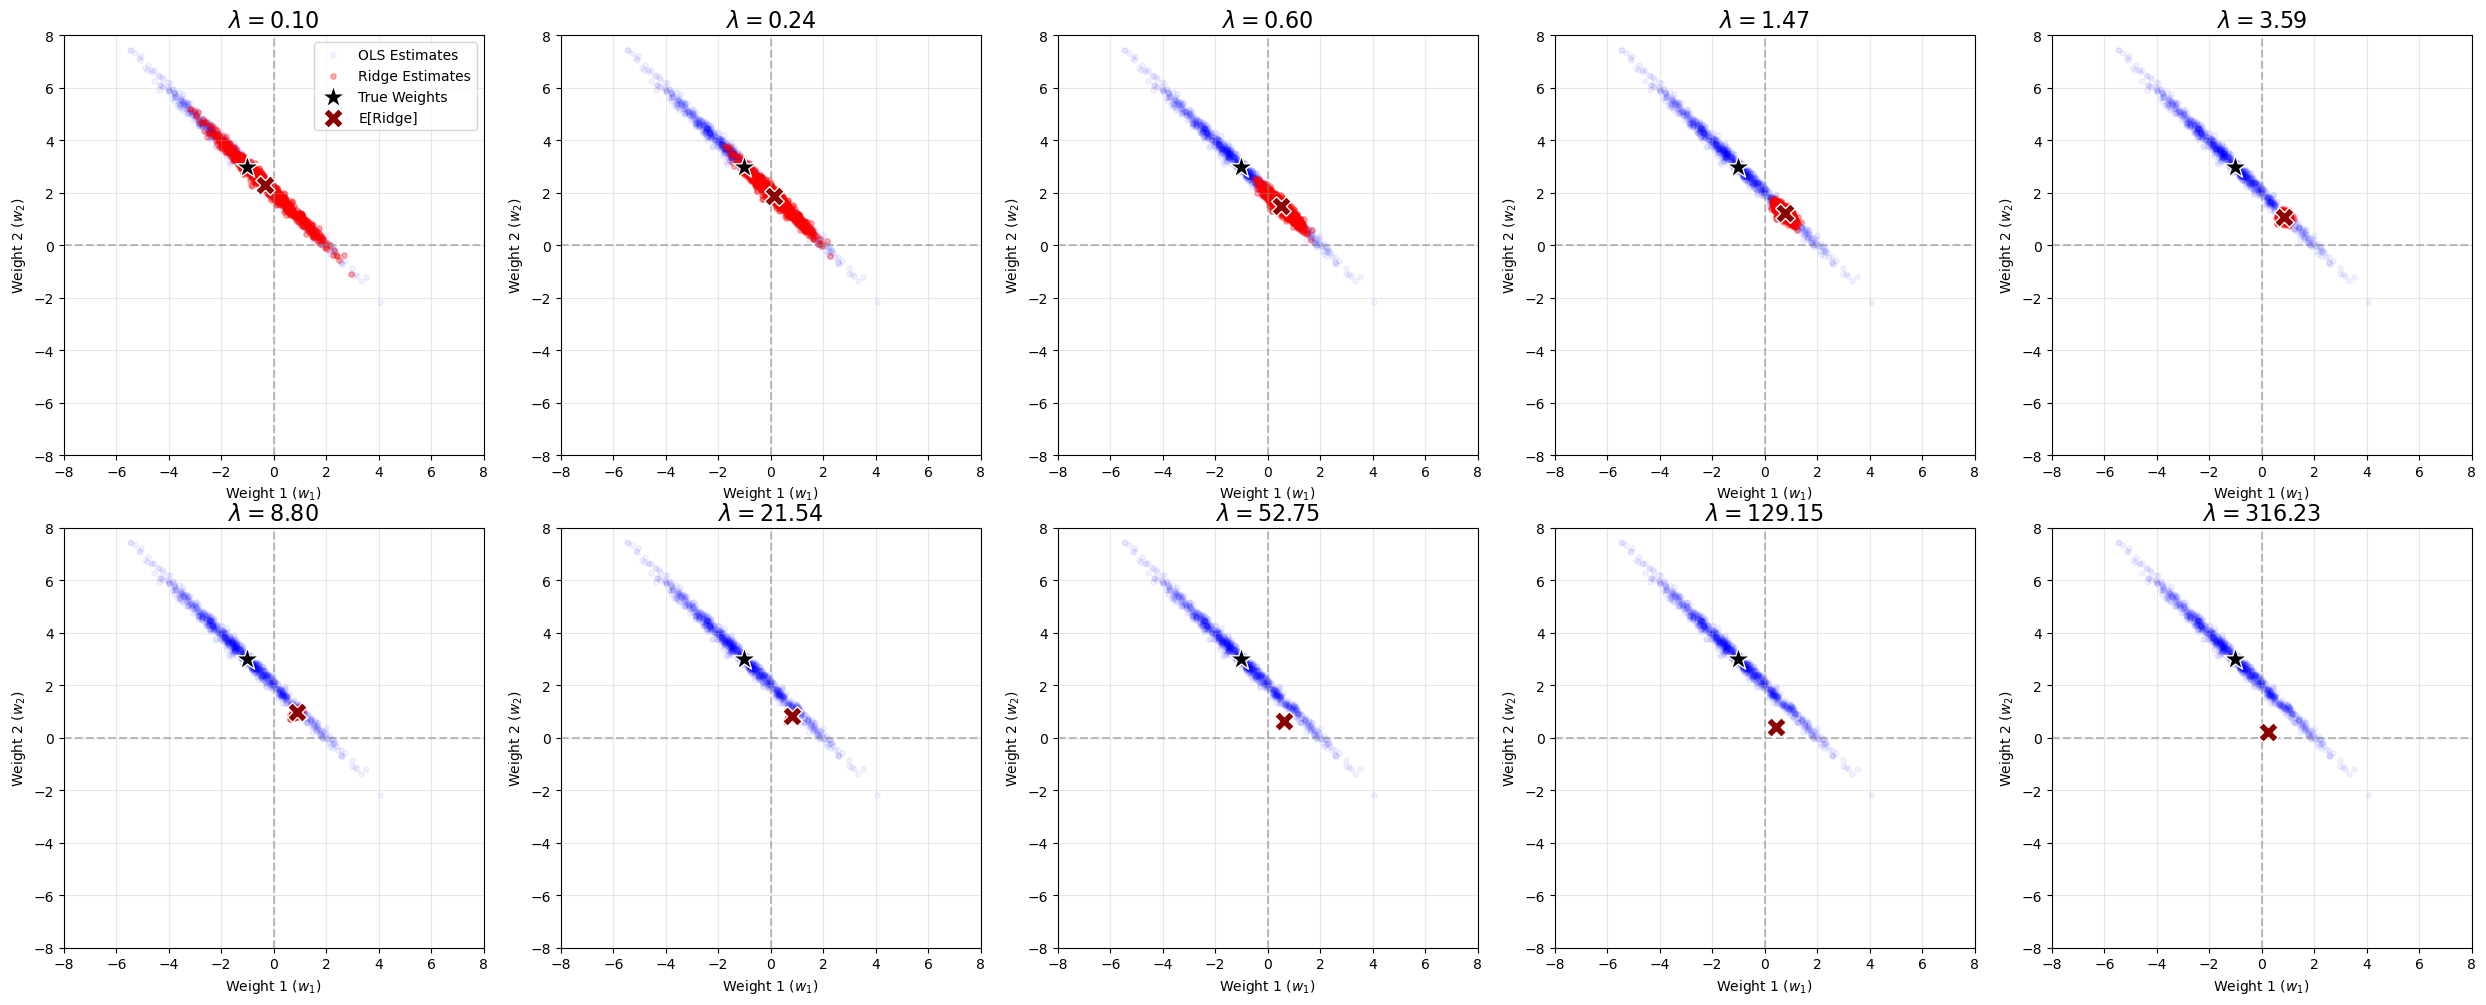

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Simulation Setup
np.random.seed(42)

n_sims = 1000
n_samples = 50
p_features = 2
sigma = 1.0

# Define the TRUE weights
w_true = np.array([-1.0, 3.0])

# Engineer severe multicollinearity: Feature 2 is almost identical to Feature 1
X1 = np.random.normal(0, 1, n_samples)
X2 = X1 + np.random.normal(0, 0.1, n_samples)
X = np.column_stack((X1, X2))

XtX = X.T @ X
XtX_inv = np.linalg.inv(XtX)

# Vectorize Monte Carlo to speed up execution by removing Python for-loops
# Y shape: (n_samples, n_sims)
Epsilon = np.random.normal(0, sigma, (n_samples, n_sims))
Y = X @ w_true[:, None] + Epsilon

# Calculate OLS estimates for all simulations simultaneously
# Resulting shape: (n_sims, p_features)
w_ols_sims = (XtX_inv @ X.T @ Y).T

# Define 10 lambda values from 0.1 to 10000 on a logarithmic scale
lambdas = np.logspace(-1, 2.5, 10)

# 2. Grid Visualization setup
fig, axes = plt.subplots(2, 5, figsize=(25, 10))
axes = axes.flatten()

for idx, lam in enumerate(lambdas):
    ax = axes[idx]

    # Calculate Ridge estimates for this specific lambda
    XtX_ridge_inv = np.linalg.inv(XtX + lam * np.eye(p_features))
    w_ridge_sims = (XtX_ridge_inv @ X.T @ Y).T

    # Expected empirical Ridge estimate
    empirical_expected_w_ridge = np.mean(w_ridge_sims, axis=0)

    # Scatter plot distributions (low alpha used for OLS to show density)
    ax.scatter(w_ols_sims[:, 0], w_ols_sims[:, 1], alpha=0.05, color='blue', label='OLS Estimates', s=15)
    ax.scatter(w_ridge_sims[:, 0], w_ridge_sims[:, 1], alpha=0.3, color='red', label='Ridge Estimates', s=15)

    # Plot true weights and expected Ridge weights
    ax.scatter(w_true[0], w_true[1], color='black', marker='*', s=300, edgecolor='white', label='True Weights', zorder=5)
    ax.scatter(empirical_expected_w_ridge[0], empirical_expected_w_ridge[1],
                color='darkred', marker='X', s=200, edgecolor='white', label='E[Ridge]', zorder=5)

    # Formatting
    ax.axvline(0, color='grey', linestyle='--', alpha=0.5)
    ax.axhline(0, color='grey', linestyle='--', alpha=0.5)
    ax.set_title(rf"$\lambda = {lam:.2f}$", fontsize=16)
    ax.set_xlabel("Weight 1 ($w_1$)")
    ax.set_ylabel("Weight 2 ($w_2$)")

    # Keep axis limits FIXED so we can visually compare shrinkage across subplots
    ax.set_xlim(-8, 8)
    ax.set_ylim(-8, 8)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

    # Only put legend on the first plot to avoid clutter
    if idx == 0:
        ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

## Bias–Variance Decomposition

The expected prediction error of a model can be decomposed as:

$[
\text{MSE} = \text{Bias}^2 + \text{Variance} + \sigma^2
]$

where:

- **Bias²** measures how far the average prediction is from the true function
- **Variance** measures how much predictions change across datasets
- **$( \sigma^2 )$** represents the **irreducible error**, i.e. the noise in the data generation process

By varying the regularization parameter $( \lambda )$, we can observe the following behavior:

- Small $( \lambda )$ → **low bias but high variance**
- Large $( \lambda )$ → **higher bias but lower variance**

The optimal model is obtained when the **total error (MSE) is minimized**, which corresponds to a balance between bias and variance.

## Exercises

Using the concepts explored in this notebook, complete the following tasks:

1. **Regularization paths**  
   Train Ridge and Lasso models for a range of regularization parameters $( \lambda )$.  
   Plot how the model coefficients change as $( \lambda )$ increases.

2. **Bias–Variance curves**  
   Using repeated simulations, estimate and plot:

   - Bias²
   - Variance
   - Mean Squared Error

   as functions of the regularization parameter.

These plots should illustrate how **regularization trades variance for bias** and why moderate regularization often improves generalization.